# Project 2: House Price Prediction

**InternCareerPath – Machine Learning (AI) Self-Learning Internship**

This project predicts California house values using regression models. It compares Linear Regression and Random Forest Regression, performs feature engineering, cross-validation, hyperparameter tuning, and error analysis.


## Objectives
- Prepare and inspect a regression dataset.
- Engineer useful features.
- Train Linear Regression and Random Forest models.
- Evaluate models using MAE and RMSE.
- Use cross-validation and hyperparameter tuning.
- Analyze prediction errors.
- Save the best trained model for future use.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib


## 1. Load the Dataset

The California Housing dataset contains numerical housing and demographic features. The target is median house value.

In [2]:
housing = fetch_california_housing(as_frame=True)
df = housing.frame.copy()

df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [3]:
print('Shape:', df.shape)
print('\nMissing values:\n', df.isnull().sum())
df.describe()

Shape: (20640, 9)

Missing values:
 MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


## 2. Feature Engineering

Ratios can provide more useful information than raw counts. We create rooms-per-household and bedrooms-per-room while protecting against division by zero.

In [4]:
df['RoomsPerHousehold'] = df['AveRooms'] / df['AveOccup'].replace(0, np.nan)
df['BedroomsPerRoom'] = df['AveBedrms'] / df['AveRooms'].replace(0, np.nan)
df = df.replace([np.inf, -np.inf], np.nan).dropna()

X = df.drop(columns='MedHouseVal')
y = df['MedHouseVal']

print('Features:', list(X.columns))
print('Rows after preprocessing:', len(df))

Features: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude', 'RoomsPerHousehold', 'BedroomsPerRoom']
Rows after preprocessing: 20640


## 3. Train/Test Split

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print('Training samples:', len(X_train))
print('Testing samples:', len(X_test))

Training samples: 16512
Testing samples: 4128


## 4. Linear Regression Baseline

In [6]:
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)
linear_pred = linear_model.predict(X_test)

linear_mae = mean_absolute_error(y_test, linear_pred)
linear_rmse = np.sqrt(mean_squared_error(y_test, linear_pred))
linear_r2 = r2_score(y_test, linear_pred)

print(f'Linear Regression MAE:  {linear_mae:.4f}')
print(f'Linear Regression RMSE: {linear_rmse:.4f}')
print(f'Linear Regression R²:   {linear_r2:.4f}')

Linear Regression MAE:  0.4862
Linear Regression RMSE: 0.6753
Linear Regression R²:   0.6519


## 5. Random Forest Regression

In [7]:
rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)

print(f'Random Forest MAE:  {rf_mae:.4f}')
print(f'Random Forest RMSE: {rf_rmse:.4f}')
print(f'Random Forest R²:   {rf_r2:.4f}')

Random Forest MAE:  0.3276
Random Forest RMSE: 0.5034
Random Forest R²:   0.8066


## 6. Model Comparison

In [8]:
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest'],
    'MAE': [linear_mae, rf_mae],
    'RMSE': [linear_rmse, rf_rmse],
    'R2': [linear_r2, rf_r2]
})
results.sort_values('RMSE')

,Model,MAE,RMSE,R2
1,Random Forest,0.327637,0.503373,0.806637
0,Linear Regression,0.486164,0.675347,0.651945


## 7. Cross-Validation

Five-fold cross-validation is used to check whether the Random Forest performance is consistent across different training/validation splits.

In [9]:
cv_scores = cross_val_score(
    rf_model, X_train, y_train,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)

print('CV RMSE scores:', -cv_scores)
print(f'Mean CV RMSE: {-cv_scores.mean():.4f}')

CV RMSE scores: [0.51404437 0.51558204 0.50514865 0.50861648 0.51283954]
Mean CV RMSE: 0.5112


## 8. Hyperparameter Tuning

GridSearchCV tests a small set of Random Forest configurations and selects the one with the lowest cross-validated RMSE.

In [10]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 15, 25],
    'min_samples_split': [2, 5]
}

grid_search = GridSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    param_grid=param_grid,
    cv=3,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)
best_model = grid_search.best_estimator_

print('Best parameters:', grid_search.best_params_)
print('Best CV RMSE:', -grid_search.best_score_)

Fitting 3 folds for each of 12 candidates, totalling 36 fits
Best parameters: {'max_depth': 25, 'min_samples_split': 2, 'n_estimators': 200}
Best CV RMSE: 0.5171787636035874


## 9. Final Evaluation

In [11]:
best_pred = best_model.predict(X_test)

final_mae = mean_absolute_error(y_test, best_pred)
final_rmse = np.sqrt(mean_squared_error(y_test, best_pred))
final_r2 = r2_score(y_test, best_pred)

print(f'Final MAE:  {final_mae:.4f}')
print(f'Final RMSE: {final_rmse:.4f}')
print(f'Final R²:   {final_r2:.4f}')

Final MAE:  0.3278
Final RMSE: 0.5037
Final R²:   0.8064


## 10. Error Analysis

Residuals are the difference between actual and predicted values. We inspect their distribution and the relationship between actual and predicted prices.

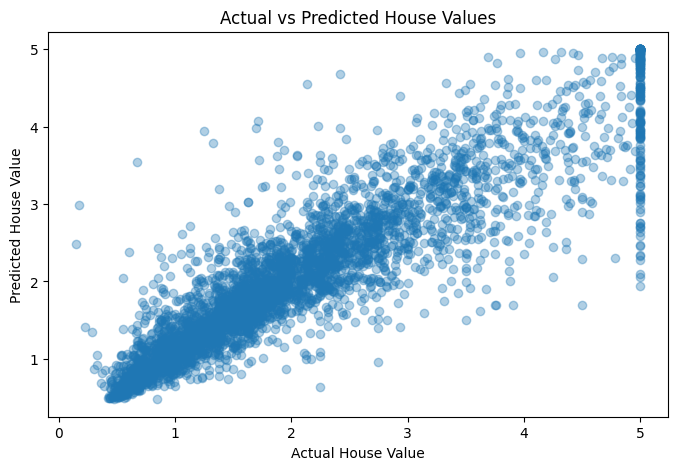

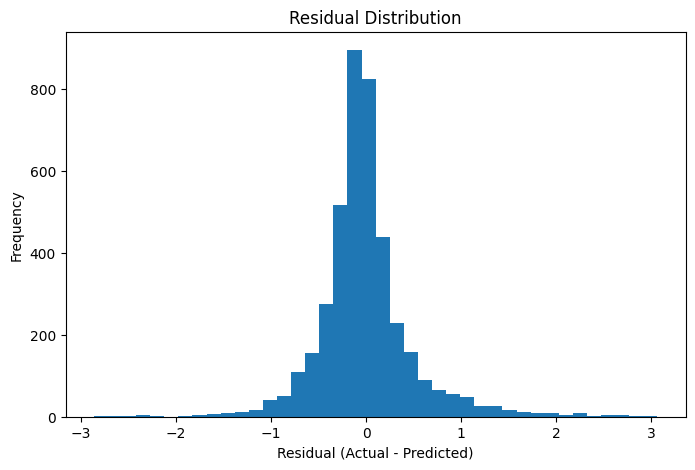

Mean residual: -0.01177809093338012
Largest absolute errors:
6688     3.063603
12389    2.947879
12069    2.899615
4548     2.862321
5887     2.817136
Name: MedHouseVal, dtype: float64


In [12]:
residuals = y_test - best_pred

plt.figure(figsize=(8, 5))
plt.scatter(y_test, best_pred, alpha=0.35)
plt.xlabel('Actual House Value')
plt.ylabel('Predicted House Value')
plt.title('Actual vs Predicted House Values')
plt.show()

plt.figure(figsize=(8, 5))
plt.hist(residuals, bins=40)
plt.xlabel('Residual (Actual - Predicted)')
plt.ylabel('Frequency')
plt.title('Residual Distribution')
plt.show()

print('Mean residual:', residuals.mean())
print('Largest absolute errors:')
print(residuals.abs().sort_values(ascending=False).head())

## 11. Feature Importance

Random Forest provides an estimate of the relative importance of each feature.

MedInc               0.522553
AveOccup             0.127483
Latitude             0.083648
Longitude            0.083616
HouseAge             0.051987
BedroomsPerRoom      0.029416
Population           0.026808
RoomsPerHousehold    0.026436
AveRooms             0.025392
AveBedrms            0.022661
dtype: float64


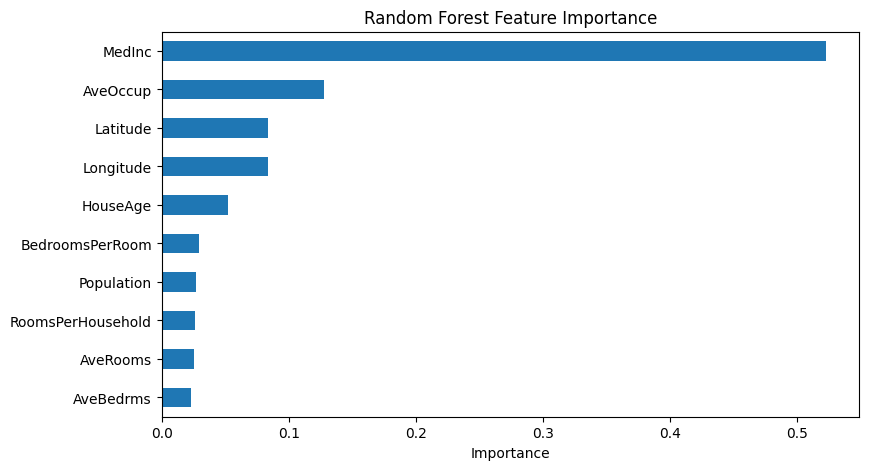

In [13]:
importance = pd.Series(
    best_model.feature_importances_, index=X.columns
).sort_values(ascending=False)

print(importance)

plt.figure(figsize=(9, 5))
importance.sort_values().plot(kind='barh')
plt.xlabel('Importance')
plt.title('Random Forest Feature Importance')
plt.show()

## 12. Save the Model

The trained model is saved as a reusable file for future predictions and experimentation.

In [14]:
joblib.dump(best_model, 'house_price_model.joblib')
print('Saved: house_price_model.joblib')

Saved: house_price_model.joblib


## Conclusion

The project compared a simple Linear Regression baseline with Random Forest Regression. Feature engineering, cross-validation, and hyperparameter tuning were applied to improve reliability. The final model was evaluated using MAE, RMSE, and R², followed by residual and feature-importance analysis. The trained model is saved as a reusable model file.